# 25 Weekly DMOs -> Fatigue

In [2]:
from src.patient_data_dispatcher import PatientDataDispatcher
from src.core.enums import MileStone, DataFrequency, PatientDataType
from src.evaluation import Evaluation
from src.core.normaliser import Normaliser
from sklearn.preprocessing import MinMaxScaler
from src.core.data_transforms import Transform
from src.train import XVRandomForest

import numpy as np
import torch

In [3]:
K_FOLDS = 5
N_VISITS = 4

In [4]:
dmo_features = [
    "wb_all_sum",
    "walkdur_all_sum",
    "wbsteps_all_sum",
    "wbdur_all_avg",
    "wbdur_all_p90",
    "wbdur_all_var",
    "cadence_all_avg",
    "strdur_all_avg",
    "cadence_all_var",
    "strdur_all_var",
    "ws_1030_avg",
    "strlen_1030_avg",
    "wb_10_sum",
    "ws_10_p90",
    "wb_30_sum",
    "ws_30_avg",
    "strlen_30_avg",
    "cadence_30_avg",
    "strdur_30_avg",
    "ws_30_p90",
    "cadence_30_p90",
    "ws_30_var",
    "strlen_30_var",
    "wb_60_sum",
]

In [5]:
static_features = [
    "weight",
    "height",
    "EDFSCR1L"
]

In [6]:
pdd = PatientDataDispatcher(
    "config/config.yaml",
    dmo_features,
    MileStone.ALL,
    data_frequency=DataFrequency.DAILY,
    physical_subset=True,
    #static_features=static_features
)
ids = list(set(pdd.metadata["Local.Participant"].to_list()))
dmo_data, dmo_labels = pdd.get_patient_data(PatientDataType.MILESTONE, ids=ids)

In [7]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

# perform impute on a visit by visit basis, as some visits are completely missing
imputer = IterativeImputer(missing_values=-1, tol=1e-2, keep_empty_features=True)
patients, visits, features, days = dmo_data.shape

for p in range(patients):
    for v in range(visits):
        visit_data = dmo_data[p, v]

        if (visit_data == -1).all():
            continue

        dmo_data[p, v] = torch.from_numpy(imputer.fit_transform(visit_data)).to(dtype=torch.float64)

/home/gwilym-rutherford/Documents/Year 3 Tuos/dissertation/Workspace/Experiment 1/.venv/lib/python3.13/site-packages/sklearn/impute/_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


In [8]:
dmo_data, dmo_labels = Transform.get_patient_visits(dmo_data, dmo_labels, n_visits=N_VISITS)

In [9]:
# remove patients that don't have a full dataset
patient_indexs = []
patient, visit, days, features = dmo_data.shape
for p in range(patient):
    all_visits = True
    for v in range(visit):
        data = dmo_data[p, v]
        label = dmo_labels[p, v]
        if (data == -1.0).any() or label == -1.0:
            all_visits = False

    if all_visits:
        patient_indexs.append(p)

dmo_data = dmo_data[patient_indexs]
dmo_labels = dmo_labels[patient_indexs]

In [10]:
print(dmo_data.shape)

torch.Size([428, 4, 7, 24])


In [11]:
# flatten to weekly summaries (this keeps patients consistent over the testing)
dmo_data = dmo_data.mean(axis=2)

In [12]:
dmo_data.shape

torch.Size([428, 4, 24])

In [13]:
# Min max normalise the labels globally

label_normaliser = Normaliser(MinMaxScaler())
dmo_labels = label_normaliser.scaler_fit_transform(dmo_labels)

In [14]:
xvregressor = XVRandomForest(dmo_data, dmo_labels, k=K_FOLDS, seed=1234)
prediction, actual = xvregressor.train_cross_validation(label_normaliser)

0.09951069844653626
0.1250598806581611
0.05250782562490275
0.007103121708177396
0.08301942364254877


In [15]:
prediction

tensor([26.0040, 26.8500, 25.5520,  ..., 17.1920, 19.6740, 18.1160],
       dtype=torch.float64)

In [16]:
xvregressor.R2_values

[0.09951069844653593,
 0.12505988065816132,
 0.05250782562490286,
 0.0071031217081770626,
 0.08301942364254888]

{'accuracy': 0.008177570093457943, 'Mean Squared Error': 64.04776763916016, 'Mean Absolute Error': 6.540003776550293, 'R^2': 0.08045873504877732}


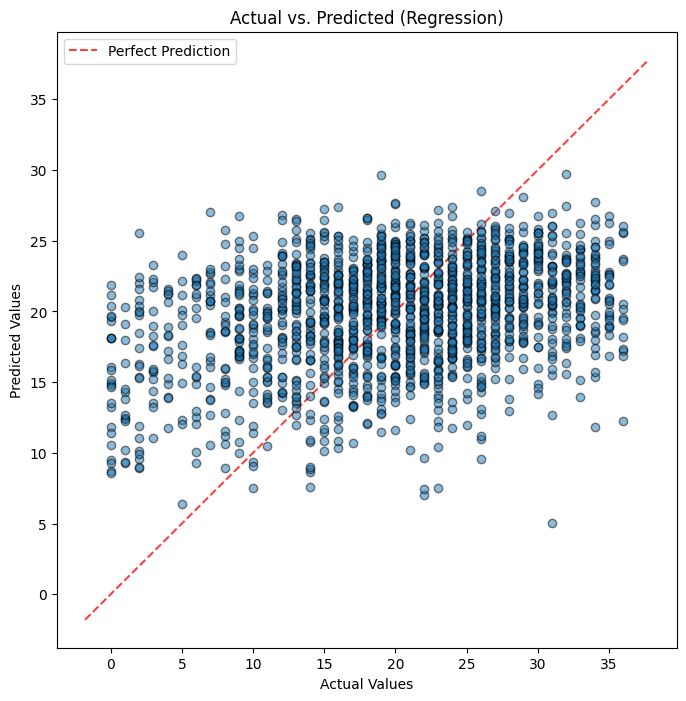

In [17]:
evaluation = Evaluation(prediction, actual)
print(evaluation.compute_all_metrics())
evaluation.evaluation_plot().show()

In [18]:
shap_values = np.concat(xvregressor.shap_values, axis=0)
test_inputs = np.concat(xvregressor.test_inputs, axis=0)
baseline_labels = np.mean(xvregressor.baseline_values)

In [19]:
dmo_data.shape

torch.Size([428, 4, 24])

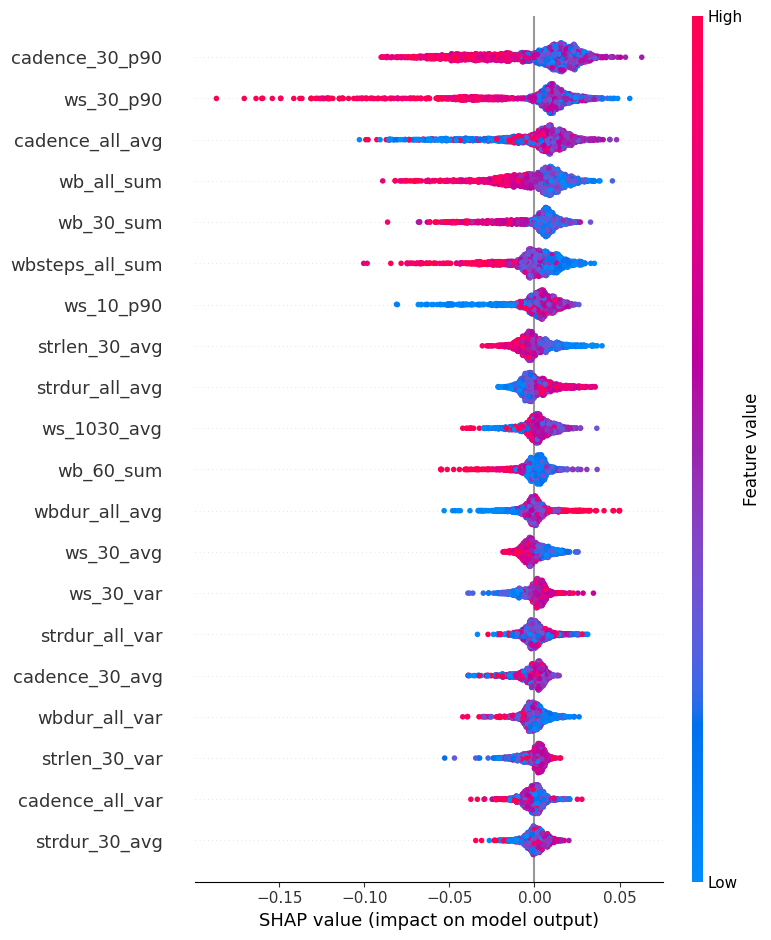

In [20]:
import shap

#dmo_features = dmo_features + static_features

shap.summary_plot(
    shap_values,
    test_inputs,
    feature_names=dmo_features,
)

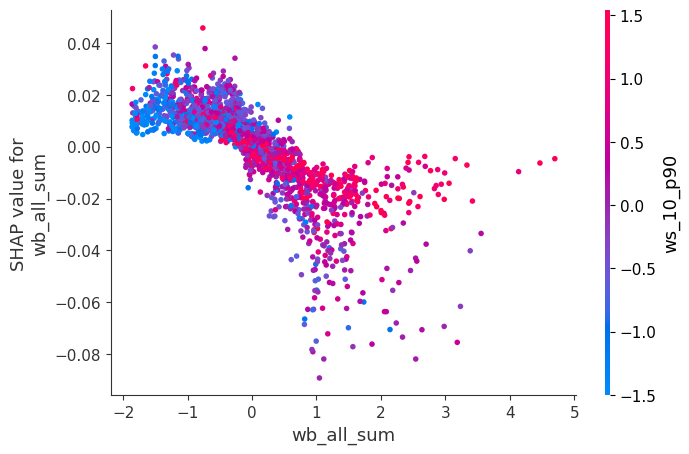

In [21]:
shap.dependence_plot(
    "wb_all_sum", 
    shap_values, 
    test_inputs, 
    feature_names=dmo_features
)

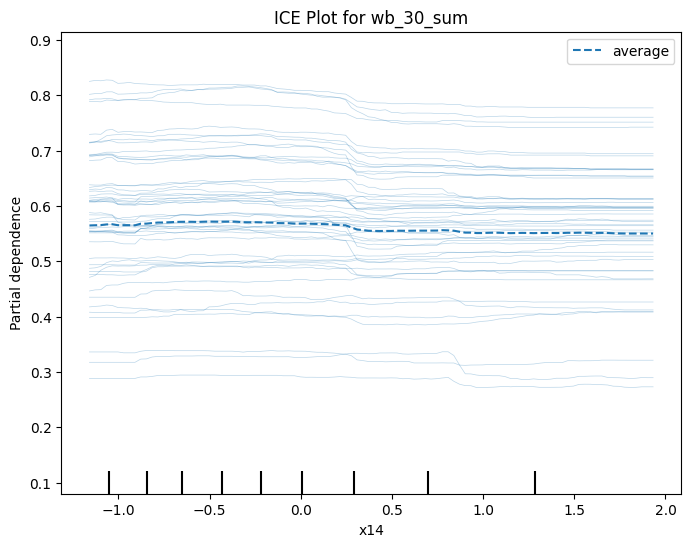

In [22]:
from sklearn.inspection import PartialDependenceDisplay
import matplotlib.pyplot as plt

feature_index = dmo_features.index("wb_30_sum")

# test_numpy = test_input.numpy()

fig, ax = plt.subplots(figsize=(8, 6))

display = PartialDependenceDisplay.from_estimator(
    xvregressor.rf_model.random_forest, 
    test_inputs, 
    features=[feature_index],
    #feature_names=dmo_features,
    kind='both', 
    subsample=50,
    ax=ax
)

ax.set_title(f"ICE Plot for {dmo_features[feature_index]}")
plt.show()

In [23]:
# # filter out less fatigued patients to see correlation

# mask = (test_label >= 0.7)
# test_numpy_filtered = test_numpy[mask]
# fig, ax = plt.subplots(figsize=(8, 6))

# display = PartialDependenceDisplay.from_estimator(
#     random_forest_model, 
#     test_numpy_filtered, 
#     features=[feature_index],
#     feature_names=dmo_features,
#     kind='both', 
#     subsample=50,
#     ax=ax
# )

# ax.set_title(f"ICE Plot for {dmo_features[feature_index]}")
# plt.show()

In [24]:
index = 1
shap.initjs()

shap.force_plot(
    baseline_labels,             
    shap_values[index],
    test_inputs[index],
    feature_names=dmo_features,
)